## Run InferAGNI static retrievals for comparison against BayesOpt evolution

In [1]:
import os
nthreads = 1
os.environ["OMP_NUM_THREADS"] = str(nthreads)
os.environ["OPENBLAS_NUM_THREADS"] = str(nthreads)
os.environ["MKL_NUM_THREADS"] = str(nthreads)

In [2]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import os
import json
import toml
from scipy.interpolate import PchipInterpolator

import matplotlib as mpl
font = {'family' : 'sans',
        'size'   : 12}

abcd = "abcdefghijklmnopqrstuvwxyz"

mpl.rc('font', **font)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, LogLocator, MaxNLocator
import matplotlib.pyplot as plt

from copy import deepcopy


import matplotlib.patheffects as pe

import pandas as pd
from cmcrameri import cm

from scipy.stats import gaussian_kde


DPI = 350


import inferagni as ia
from inferagni.plot import load_melting_data, calc_Tdemix
from inferagni.util import atom_map, mmw_map

from inferagni.retrieve import run_retrieval, plot_corner

In [3]:
# THESIS_DIR = "/home2/p321409/Projects/thesis_pipeline"
# SIM_DIR = "data/scratch/"

# THESIS_DIR = "/home/harrison/Projects/thesis_pipeline"
# SIM_DIR = "data/"

THESIS_DIR = "/data/hen28/Projects/thesis_pipeline"
SIM_DIR = "data/bayesopt_recent/"

In [4]:
# %config InlineBackend.figure_format = 'retina'

In [5]:
meltcurves = load_melting_data()

In [6]:
gr = ia.grid.Grid(derive_extra=True, emits=False, profs=False)

Loading data from disk...
    Source: /data/hen28/Projects/InferAGNI/src/inferagni/data/grid_022
Loading grid of scalar quantities
Deriving additional quantities
    H_phot
    log_vmr_*
    log_Kzz_max
    C/O
    O/H
    S/O
    N/O
    Grid size: 504000 points
    Input vars:
      Teff            : range [2500      , 6500      ]
      instellation    : range [1         , 1000      ]
      logZ            : range [-2        , 1         ]
      logCO           : range [-3        , 0         ]
      mass_tot        : range [1         , 10        ]
      frac_core       : range [0.2       , 0.7       ]
      frac_atm        : range [0.000562  , 0.25      ]
    Output vars: 
      succ, flux_loss_max, r_bound, p_surf,
      t_surf, r_surf, μ_surf, g_surf, t_phot,
      r_phot, μ_phot, g_phot, vmr_H2,
      vmr_H2O, vmr_CO2, vmr_CO, vmr_O2,
      vmr_OH, vmr_NH3, vmr_NO2, vmr_N2,
      vmr_SO2, vmr_H2S, vmr_H2SO4, Kzz_max,
      conv_ptop, conv_pbot, flux_loss_med,
      flux_toa, flux_b

In [7]:
# map PROTEUS keys to inferAGNI observables
def key_map(ia_key, hf_row):

    match ia_key:
        case "t_phot": return hf_row["T_obs"]
        case "r_phot": return hf_row["R_obs"] / ia.util.R_earth
        case "mass_tot": return hf_row["M_planet"] / ia.util.M_earth
        case "μ_phot": return hf_row["atm_kg_per_mol"] / 1e-3 # kg/mol to g/mol
        case "instellation": return hf_row["F_ins"] / ia.util.S_earth
        case "Teff": return hf_row["T_star"] / 1.0
        case "frac_atm": return hf_row["M_atm"]/hf_row["M_planet"]
        case "frac_core": return hf_row["M_core"]/hf_row["M_planet"]
        case "p_surf": return hf_row["P_surf"] #/ 1e5 # bar to Pa
        case "t_surf": return hf_row["T_surf"] 
        case "r_surf": return hf_row["R_int"] / ia.util.R_earth
        case "g_phot": return hf_row["g_obs"]

    # log vmr
    if ia_key.startswith("log_vmr_"):
        species = ia_key.split("_")[-1]
        return np.log10(hf_row[f"{species}_vmr"])

    # vmr
    if ia_key.startswith("vmr_"):
        species = ia_key.split("_")[-1]
        return hf_row[f"{species}_vmr"]
    
    # metallicity ratios from vmrs
    if ia_key in ["C/O", "O/H", "S/O", "N/O"]:
        e1, e2 = ia_key.split("/")
        m1 = 0.0
        m2 = 0.0
        # loop through molecules and sum up the contributions to the 
        #     abundances of each element in this ratio
        for species, stoich in atom_map.items():
            if f"{species}_vmr" not in hf_row:
                continue
            if e1 in stoich:
                m1 += stoich[e1] * hf_row[f"{species}_vmr"] * mmw_map[e1]
            if e2 in stoich:
                m2 += stoich[e2] * hf_row[f"{species}_vmr"] * mmw_map[e2]
        if m2 == 0.0:
            return 0.0
        return m1 / m2

    raise ValueError(f"Unknown key {ia_key}")

In [8]:
bo_cols = {
    "sn": 'tab:blue',
    "se": 'tab:orange',
    "tr": 'tab:green'
}

bo_tits = {
    "sn": "Sub-Neptune",
    "se": "Super-Earth",
    "tr": "Terrestrial"
}

bo_suffixes = ('sn', 'se', 'tr')


In [9]:
def get_bo_run(output_dir):

    output_dir = os.path.abspath(output_dir)
    print("Reading BO run from", output_dir)

    # check folder exists
    if not os.path.isdir(output_dir):
        print(f"Folder {output_dir} does not exist.")
        return None

    # Read BO config file
    config_path = os.path.join(output_dir, "copy.infer.toml")
    infer_conf = toml.load(config_path)
    obs = infer_conf['observables']
    prs = infer_conf['parameters']

    # Extract log of BO run
    if not os.path.isfile(os.path.join(output_dir, "logs.csv")):
        print(f"Log file not found in {output_dir}.")
        return None
    fpath = os.path.join(output_dir, "logs.csv")
    log = []
    best_obj = -np.inf
    with open(fpath, 'r') as f:
        for line in f.readlines():
            if '{' not in line:
                continue
            line = line.replace("'", '"').replace("None", "1.0")[1:-2]
            json_line = json.loads(line) # parse json into dict
            log.append(json_line)

            if json_line['y_value'] > best_obj:
                best_obj = json_line['y_value']

    # Mark best worker
    is_best = np.full(len(log), False, dtype=bool)
    for i, run in enumerate(log):
        if run['y_value'] == best_obj:
            is_best[i] = True
    print("    best worker:", np.where(is_best)[0], "with y =", best_obj)

    # For each worker, read helpfile
    helps = []
    confs = []
    objs = []
    for run in log:
        wk = run['worker']
        id = run['task_id']

        help_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "runtime_helpfile.csv")
        if not os.path.isfile(help_path):
            print(f"Helpfile not found for worker {wk}, task {id}.")
            continue
        helps.append(pd.read_csv(help_path, delimiter=r"\s+"))

        conf_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "input.toml")
        confs.append(toml.load(conf_path))
        objs.append(run['y_value'])

    # Package into dict
    bo_run = {
        "config": infer_conf,
        "log": log,
        "helps": helps,
        "confs": confs,
        "obs": obs,
        "prs": prs,
        "objectives": objs,
        "is_best": is_best,
    }
    print(objs)
    return bo_run

def get_gt_run(gt_dir):

    # Read GT config file
    config_path = os.path.join(gt_dir, "init_coupler.toml")
    gt_conf = toml.load(config_path)

    # Read GT helpfile
    help_path = os.path.join(gt_dir, "runtime_helpfile.csv")
    help_path = os.path.abspath(help_path)
    print("Reading GT helpfile from", help_path)
    gt_help = pd.read_csv(help_path, delimiter=r"\s+")

    gt_run = {
        "config": gt_conf,
        "help": gt_help,
        "outdir": gt_dir
    }
    return gt_run


# baseline parameters
bl_suf = 'tr'
bl_acq = 'lei'
bl_ker = 'mat12'
bl_wrk = '5'
bl_stp = '100'

print("Baseline parameters:")
print(f"  Suffix: {bl_suf}")
print(f"  Acquisition function: {bl_acq}")
print(f"  Kernel: {bl_ker}")
print(f"  Workers: {bl_wrk}")
print(f"  Steps: {bl_stp}")

# Read ground truth config and results
ground_truth = {}
bo_data = {}
for suf in bo_suffixes:
    ground_truth[suf] = get_gt_run(f"{SIM_DIR}/bayesopt_{suf}/")

    ker = bl_ker
    acq = bl_acq
    wrk = bl_wrk
    stp = bl_stp
    bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}_{ker}_{acq}_{wrk}_{stp}/"
    bo_data[suf] = get_bo_run(bo_dir)

# Read BO inference results
obs_list = list(list(bo_data.values())[0]['obs'].keys())
prs_list = list(list(bo_data.values())[0]['prs'].keys())

Baseline parameters:
  Suffix: tr
  Acquisition function: lei
  Kernel: mat12
  Workers: 5
  Steps: 100
Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_sn/runtime_helpfile.csv
Reading BO run from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_sn_mat12_lei_5_100
    best worker: [95] with y = -0.34568817294240833
[-2.340371231541602, -2.3396795656433933, -2.3399424600528707, -2.3389986817590107, -2.339674646395464, -1.2025720986331265, -1.148294752910311, -0.8863252810509096, -0.8518505142147885, -1.3165918625877866, -0.7008837419865733, -0.7201525079749244, -0.638384346749664, -1.0986797022354937, -0.8905735998930152, -1.1280274015426082, -1.0486366507805114, -0.934809756489403, -0.9246075860514839, -0.9146905493033819, -0.7348612481467214, -0.7183674586714507, -0.7019497510524416, -0.7190594980137177, -0.6813318450367623, -0.5831045952534665, -0.5820894278939939, -0.5993673743266082, -0.5796617554991327, -0.578501

In [10]:
# Relative uncertainty on each observable
rel_unc = 0.1

# Make observables
gt_obs = {}
for suf in ground_truth.keys():

    # any keys in this dict will get picked up as contraining observables
    obs_pl = {
        "_name":  suf,
        
        # fixed by config
        "mass_tot": None,
        "instellation": None,
        "Teff": None,
        
        # final row from GT run
        "r_phot": None,
        "t_phot": None,
        "g_phot": None,
        "μ_phot": None,
        "C/O": None,
        "S/O": None,
        "O/H": None,
    }
    for ia_key in obs_pl.keys():
        if ia_key.startswith("_"):
            continue
        val = key_map(ia_key, ground_truth[suf]["help"].iloc[-1])
        err = val * rel_unc
        obs_pl[ia_key] = [val, err]

    print(f"Ground truth for {suf}:")
    print("\n".join(f"    {k}: {v[0]} +/- {v[1]}" for k, v in obs_pl.items()))

    gt_obs[suf] = obs_pl
    print(" ")

Ground truth for sn:
    _name: s +/- n
    mass_tot: 3.064782039517749 +/- 0.30647820395177494
    instellation: 2.85386657898604 +/- 0.285386657898604
    Teff: 3431.1444064 +/- 343.11444064000005
    r_phot: 1.919259307644012 +/- 0.19192593076440123
    t_phot: 313.06404106 +/- 31.306404106000002
    g_phot: 8.0918693165 +/- 0.8091869316500001
    μ_phot: 4.0917808871 +/- 0.40917808871
    C/O: 3.1927022037399078 +/- 0.3192702203739908
    S/O: 1.067864058794092 +/- 0.1067864058794092
    O/H: 0.1622147995887899 +/- 0.01622147995887899
 
Ground truth for se:
    _name: s +/- e
    mass_tot: 2.036838676657736 +/- 0.20368386766577362
    instellation: 6.521919197060985 +/- 0.6521919197060986
    Teff: 3431.3233503 +/- 343.13233503000004
    r_phot: 1.452413888636007 +/- 0.1452413888636007
    t_phot: 409.23645346 +/- 40.923645346
    g_phot: 9.1084971059 +/- 0.91084971059
    μ_phot: 18.86649216 +/- 1.8866492160000001
    C/O: 0.8664113771983287 +/- 0.08664113771983288
    S/O: 0.5652

In [11]:
def get_outdir(suf):
    outdir_planet = os.path.join("output/", suf)
    return outdir_planet

In [12]:
for suf in bo_data.keys():

    outdir_planet = get_outdir(suf)
    print(f"Saving to {outdir_planet}")

    # remove old files
    os.makedirs(outdir_planet, exist_ok=True)
    for f in ("result.csv", "truth.csv", "corner.pdf", "emits.pdf", "profs.pdf"):
        f = os.path.join(outdir_planet, f)
        if os.path.exists(f):
            os.remove(f)

Saving to output/sn
Saving to output/se
Saving to output/tr


In [13]:
# Extra keys to get from grid
extra_keys = ["p_surf", "t_surf",
               "g_surf", "r_surf",
                "log_vmr_H2O", "N/O",
             ] 

# Do retrieval for each case
gt_ret = {}
for suf in bo_data.keys():
    print(suf)
    outdir_planet = get_outdir(suf)

    # get observables
    obs = gt_obs[suf]

    # do retrieval with MCMC
    keys, samples = run_retrieval(gr, obs,
                                    n_walkers=14, n_procs=14, 
                                    n_steps=4000, thin=4, filter_ineq=True,
                                    extra_keys=extra_keys)

    # store results
    gt_ret[suf] = {
        "obs": obs,
        "keys": keys,
        "samples": samples,
        "outdir": outdir_planet
    }


    # write csv
    ia.retrieve.write_result(keys,samples, f"{outdir_planet}/result.csv");
    ia.retrieve.write_truth(f"{outdir_planet}/truth.csv");

    # make plot
    fig = plot_corner(keys, samples,show=False)
    fig.savefig(f"{outdir_planet}/corner.pdf", bbox_inches='tight',dpi=ia.plot.DPI)

sn
Prepare interpolators
Creating linear interpolator on logZ
    Interpolator ready
Creating linear interpolator on μ_phot
    Interpolator ready
Creating linear interpolator on t_surf
    Interpolator ready
Creating linear interpolator on instellation
    Interpolator ready
Creating linear interpolator on log_vmr_H2O
    Interpolator ready
Creating linear interpolator on N/O
    Interpolator ready
Creating linear interpolator on O/H
    Interpolator ready
Creating linear interpolator on logCO
    Interpolator ready
Creating linear interpolator on Teff
    Interpolator ready
Creating linear interpolator on frac_atm
    Interpolator ready
Creating linear interpolator on C/O
    Interpolator ready
Creating linear interpolator on r_surf
    Interpolator ready
Creating linear interpolator on g_phot
    Interpolator ready
Creating linear interpolator on frac_core
    Interpolator ready
Creating linear interpolator on p_surf
    Interpolator ready
Creating linear interpolator on g_surf
    

 15%|█▌        | 600/4000 [00:50<04:41, 12.07it/s]

100%|██████████| 4000/4000 [05:37<00:00, 11.87it/s]


    done
 
Discarded 80 burn-in samples and thinned by 4
Samples: (13720, 7), length 96040

Postprocessing grid with extra keys: ['μ_phot', 'C/O', 'r_surf', 'g_phot', 'p_surf', 't_surf', 'g_surf', 'r_phot', 'log_vmr_H2O', 'N/O', 'O/H', 'S/O', 't_phot']
    done

Filtering samples to satisfy inequality constraints
New sample size after filtering: 13720

    Quantity    :    Median         (Uncertainty)             Autocorrelation
Teff            :     3296.1  (+ 122.008     - 52.5269   )    249.2856
instellation    :    4.77632  (+ 1.68443     - 1.56473   )    206.1662
logZ            :  -0.777922  (+ 0.241027    - 0.0779159 )    324.1016
logCO           :   -1.38735  (+ 1.25942     - 1.53069   )    370.6612
mass_tot        :    3.17319  (+ 0.256939    - 0.264377  )    202.1149
frac_core       :   0.386037  (+ 0.199653    - 0.132849  )    231.9466
frac_atm        : 0.00256088  (+ 0.00292433  - 0.00159318)    237.9474
μ_phot          :    2.40714  (+ 0.264284    - 0.0702031 )
C/O        

se
Prepare interpolators
Interpolator already initialised on logZ
Interpolator already initialised on μ_phot
Interpolator already initialised on t_surf
Interpolator already initialised on instellation
Interpolator already initialised on log_vmr_H2O
Interpolator already initialised on N/O
Interpolator already initialised on O/H
Interpolator already initialised on logCO
Interpolator already initialised on Teff
Interpolator already initialised on frac_atm
Interpolator already initialised on C/O
Interpolator already initialised on r_surf
Interpolator already initialised on g_phot
Interpolator already initialised on frac_core
Interpolator already initialised on p_surf
Interpolator already initialised on g_surf
Interpolator already initialised on r_phot
Interpolator already initialised on S/O
Interpolator already initialised on mass_tot
Interpolator already initialised on t_phot
 
Copy grid object into module global scope
Observables:
    mass_tot        :    2.03684 ± 0.203684  
    instell

100%|██████████| 4000/4000 [05:34<00:00, 11.97it/s]
N/50 = 80;
tau: [257.21898332 320.45031081 238.91269848 381.77028993 330.69339585
 313.09378994 409.52305267]


    done
 
Discarded 80 burn-in samples and thinned by 4
Samples: (13720, 7), length 96040

Postprocessing grid with extra keys: ['μ_phot', 'C/O', 'r_surf', 'g_phot', 'p_surf', 't_surf', 'g_surf', 'r_phot', 'log_vmr_H2O', 'N/O', 'O/H', 'S/O', 't_phot']
    done

Filtering samples to satisfy inequality constraints
New sample size after filtering: 13720

    Quantity    :    Median         (Uncertainty)             Autocorrelation
Teff            :    3304.39  (+ 510.323     - 670.004   )    257.2190
instellation    :     11.997  (+ 3.88258     - 2.79412   )    320.4503
logZ            :   0.463734  (+ 0.0355615   - 2.40827   )    238.9127
logCO           :  -0.228051  (+ 0.195615    - 1.96692   )    381.7703
mass_tot        :    1.96488  (+ 0.280382    - 0.225345  )    330.6934
frac_core       :   0.334842  (+ 0.253153    - 0.109028  )    313.0938
frac_atm        : 0.000999152  (+ 0.0121149   - 0.000348723)    409.5231
μ_phot          :    8.50799  (+ 0.63019     - 6.46583   )
C/O      

tr
Prepare interpolators
Interpolator already initialised on logZ
Interpolator already initialised on μ_phot
Interpolator already initialised on t_surf
Interpolator already initialised on instellation
Interpolator already initialised on log_vmr_H2O
Interpolator already initialised on N/O
Interpolator already initialised on O/H
Interpolator already initialised on logCO
Interpolator already initialised on Teff
Interpolator already initialised on frac_atm
Interpolator already initialised on C/O
Interpolator already initialised on r_surf
Interpolator already initialised on g_phot
Interpolator already initialised on frac_core
Interpolator already initialised on p_surf
Interpolator already initialised on g_surf
Interpolator already initialised on r_phot
Interpolator already initialised on S/O
Interpolator already initialised on mass_tot
Interpolator already initialised on t_phot
 
Copy grid object into module global scope
Observables:
    mass_tot        :    1.01427 ± 0.101427  
    instell

100%|██████████| 4000/4000 [05:42<00:00, 11.66it/s]
N/50 = 80;
tau: [116.2249485  165.09453667 113.85841738  94.80349557 121.68059995
 165.12914488 116.65393998]


    done
 
Discarded 80 burn-in samples and thinned by 4
Samples: (13720, 7), length 96040

Postprocessing grid with extra keys: ['μ_phot', 'C/O', 'r_surf', 'g_phot', 'p_surf', 't_surf', 'g_surf', 'r_phot', 'log_vmr_H2O', 'N/O', 'O/H', 'S/O', 't_phot']
    done

Filtering samples to satisfy inequality constraints
New sample size after filtering: 13720

    Quantity    :    Median         (Uncertainty)             Autocorrelation
Teff            :    3421.68  (+ 329.899     - 327.831   )    116.2249
instellation    :    36.3579  (+ 12.0658     - 12.0522   )    165.0945
logZ            :   0.966491  (+ 0.0247834   - 0.0473393 )    113.8584
logCO           :  -0.754651  (+ 0.0645824   - 0.0520115 )    94.8035
mass_tot        :    1.07207  (+ 0.0727476   - 0.0511768 )    121.6806
frac_core       :   0.415679  (+ 0.163359    - 0.144454  )    165.1291
frac_atm        :  0.0035413  (+ 0.00683763  - 0.00213413)    116.6539
μ_phot          :    18.4929  (+ 0.538214    - 1.01308   )
C/O         

### Compare static against evolutionary model, for each planet

In [29]:
KDE_ALPHA_MIN = 0.05
KDE_ALPHA_MAX = 0.50

def _kde2d(ax, x, y, log_x=False, log_y=False, n_levels=5, 
           resolution=100, zorder=1, col='grey', label=None):
    """2D KDE contours with independent log/linear transform per axis."""
    xd = np.log10(np.asarray(x, float)) if log_x else np.asarray(x, float)
    yd = np.log10(np.asarray(y, float)) if log_y else np.asarray(y, float)
    mask = np.isfinite(xd) & np.isfinite(yd)
    xd, yd = xd[mask], yd[mask]
    if len(xd) < 20:
        return
    kde = gaussian_kde(np.vstack([xd, yd]))
    pad_x = 0.1 * (xd.max() - xd.min())
    pad_y = 0.1 * (yd.max() - yd.min())
    xi = np.linspace(xd.min() - pad_x, xd.max() + pad_x, resolution)
    yi = np.linspace(yd.min() - pad_y, yd.max() + pad_y, resolution)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    z_vals = Zi[Zi > Zi.max() * 0.01]
    if len(z_vals) == 0:
        return
    levels = np.quantile(z_vals, np.linspace(0.0, 1.0, n_levels + 1))
    Xp = 10**Xi if log_x else Xi
    Yp = 10**Yi if log_y else Yi
    alphas = np.linspace(KDE_ALPHA_MIN, KDE_ALPHA_MAX, n_levels)
    for k in range(n_levels):
        lo = levels[k]
        hi = levels[k + 1] if k + 1 < n_levels else Zi.max() * 1.01
        ax.contourf(
            Xp,
            Yp,
            Zi,
            levels=[lo, hi],
            colors=[col],
            alpha=alphas[k],
            zorder=zorder,
        )  # noqa: F405
    cont = ax.contour(
        Xp,
        Yp,
        Zi,
        levels=levels,
        colors=[col],  # noqa: F405
        alpha=KDE_ALPHA_MAX,
        zorder=zorder,
    )

    patch= ax.add_patch(mpl.patches.Rectangle((np.median(Xp), np.median(Yp)), 0.0, 0.0, alpha=KDE_ALPHA_MAX,facecolor=col,label=label))

    return patch


In [31]:
def tsat(p):
    # 1 celcius
    _t = np.array([20 , 25 , 30 , 34 , 40 , 44 , 50 , 54 , 60 , 70 , 80 , 90 , 96 , 100, 110, 120, 130, 140, 150, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 370], dtype=float)
    _t += 273.15

    # 1 kPa = 100 bar
    _p = np.array([2.3393 , 3.1699 , 4.2470 , 5.3251 , 7.3849 , 9.1124 , 12.352 , 15.022 , 19.946 , 31.201 , 47.414 , 70.182 , 87.771 , 101.42 , 143.38 , 198.67 , 270.28 , 361.54 , 476.16 , 618.23 , 1002.8 , 1554.9 , 2319.6 , 3346.9 , 4692.3 , 6416.6 , 8587.9 , 11284 , 14601 , 18666 , 21044 ])
    _p /= 100

    return np.interp(np.log10(p), np.log10(_p), _t,  right=np.nan)

t_surf = 1502.50 (+96.72 -173.15)
p_surf = 8802.49 (+9976.68 -6263.40)
r_phot = 1.82 (+0.15 -0.12)
BO objectives range from -2.340 to -0.346
    best worker 95 with objective -0.346
    final point: 1625.55, 11989.72
Ground truth final: 1796.64, 22271.20, 1.92


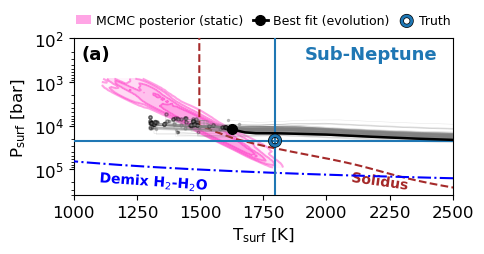

t_surf = 1385.68 (+35.62 -222.29)
p_surf = 1311.17 (+1013.97 -207.51)
r_phot = 1.36 (+0.36 -0.05)
BO objectives range from -1.108 to -0.199
    best worker 72 with objective -0.199
    final point: 1346.48, 1945.70
Ground truth final: 1913.55, 42787.92, 1.45


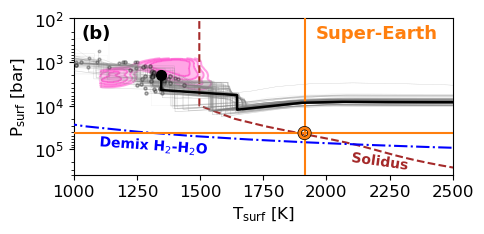

t_surf = 1554.85 (+140.72 -103.24)
p_surf = 4687.70 (+8552.19 -2711.90)
r_phot = 1.10 (+0.05 -0.06)
BO objectives range from -9.536 to 1.330
    best worker 68 with objective 1.330
    final point: 1378.54, 4816.00
Ground truth final: 1555.70, 8220.57, 1.07


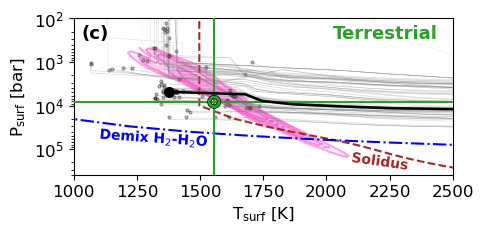

In [50]:
iplt =0

def comp_evol_stat(suf):
    global iplt

    outdir_planet = gt_ret[suf]["outdir"]
    keys = gt_ret[suf]["keys"]
    samples = gt_ret[suf]["samples"]

    samps = pd.read_csv(os.path.join(outdir_planet,"result.csv"),skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(os.path.join(outdir_planet,"truth.csv") ,skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # get last samples from samps
    end_frac = 0.05
    nsamp = int(len(samps)*end_frac)
    samps = samps.iloc[-nsamp:]

    ckey = "r_phot"   ; cfmt = "%.2f"

    xkey = "t_surf" ; xfmt = "%.2f"
    xlabel = r"T$_{\rm surf}$ [K]"
    xmin = 1000
    xmax = 2500

    ylabel = r"P$_{\rm surf}$ [bar]"
    ykey = "p_surf"; yfmt = "%.2f"
    ymin = 1e2
    ymax = 4e5

    fig,ax = plt.subplots(1,1,figsize=(5,2.5))

    al = 0.2
    ms = 3

    if ia.util.varprops[ckey].log:
        c = 10**(samps[ckey].values)
    else:
        c = samps[ckey].values
    mask = np.argsort(c)[::-1]

    x = ia.util.nondimen(samps[xkey].iloc[mask], xkey)
    y = ia.util.nondimen(samps[ykey].iloc[mask], ykey)
    c = ia.util.nondimen(c[mask], ckey)
    c = np.nan_to_num(c, nan=np.nanmax(c))

    # mcmc result
    x_med = np.median(x); x_err=[  [np.median(x)-np.percentile(x, 16)], [np.percentile(x, 84)-np.median(x)]]
    print(xkey + " = "+str(xfmt)%x_med + " (+"+str(xfmt)%x_err[1][0] + " -"+str(xfmt)%x_err[0][0] + ")")
    y_med = np.median(y); y_err=[ [np.median(y)-np.percentile(y, 16)], [np.percentile(y, 84)-np.median(y)],]
    print(ykey + " = "+str(yfmt)%y_med + " (+"+str(yfmt)%y_err[1][0] + " -"+str(yfmt)%y_err[0][0] + ")")
    c_med = np.median(c); c_err=[[np.median(c)-np.percentile(c, 16)], [np.percentile(c, 84)-np.median(c)]]
    print(ckey + " = "+str(cfmt)%c_med + " (+"+str(cfmt)%c_err[1][0] + " -"+str(cfmt)%c_err[0][0] + ")")

    # show mcmc output as scatter
    # ax.scatter(x,y, color='grey', 
    #            s=ms,  alpha=al, 
    #            edgecolors="none", rasterized=True)

    # show mcmc output as KDE
    # ax.tricontourf(x, y, c, levels=10, cmap='Purples', alpha=0.5, zorder=1, label="MCMC posterior")
    _kde2d(ax, x, y, log_x=ia.util.varprops[xkey].log, log_y=ia.util.varprops[ykey].log,
           n_levels=4,  resolution=40,
           zorder=1, col="#FF4CCC", label="MCMC posterior (static)")

    # samples from BO runs
    obj_min = np.amin([obj for obj in bo_data[suf]["objectives"] if obj > -15])
    obj_max = np.amax(bo_data[suf]["objectives"])
    print(f"BO objectives range from {obj_min:.3f} to {obj_max:.3f}")
    # cmap = deepcopy(plt.get_cmap("Reds"))
    # boundaries = np.linspace(obj_min, obj_max, 7)
    # norm = mpl.colors.BoundaryNorm(boundaries=boundaries, ncolors=cmap.N)
    # sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    # cbar = fig.colorbar(sm, ax=ax, label="Objective", pad=0.01, extend='min', aspect=9)
    # cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%+.1f'))

    for i in range(len(bo_data[suf]["helps"])):
        hf_all = bo_data[suf]["helps"][i]
        
        xrun_arr = [key_map(xkey, row) for _, row in hf_all.iterrows()]
        yrun_arr = [key_map(ykey, row) for _, row in hf_all.iterrows()]

        # get alpha from normalised objective value
        obj = bo_data[suf]["objectives"][i]
        if obj<-15:
            continue

        alpha = 0.4 * (obj - obj_min) / (obj_max - obj_min)
        zo = 9
        color = 'grey'
        

        # is best?
        if bo_data[suf]["is_best"][i]:
            color = 'k'
            alpha = 1.0
            zo = 10
            ms = 7*alpha
            lw = 1.8*alpha
            lbl = "Best fit (evolution)"
            print(f"    best worker {i} with objective {obj:.3f}")
            print("    final point: "+str(xfmt)%xrun_arr[-1]+", "+str(yfmt)%yrun_arr[-1])
        else:
            lbl = ""
            lw = 1.2*alpha
            ms = 6*alpha

        ax.plot(xrun_arr, yrun_arr, lw=lw, 
                color=color, alpha=alpha, zorder=zo)
        
        # end point
        ax.plot([xrun_arr[-1]], [yrun_arr[-1]],  markersize=ms,  marker='o',
                   alpha=alpha, color=color, zorder=zo, lw=2,
                   markeredgecolor="k", label=lbl)

    # ground truth evolution model, loop through rows to make path
    hf_all = ground_truth[suf]["help"]
    xtruth_arr = [key_map(xkey, row) for _, row in hf_all.iterrows()]
    ytruth_arr = [key_map(ykey, row) for _, row in hf_all.iterrows()]
    ctruth_arr = [key_map(ckey, row) for _, row in hf_all.iterrows()]
    ctruth_color = bo_cols[suf]
    xtruth_fin = xtruth_arr[-1]
    ytruth_fin = ytruth_arr[-1]
    ax.scatter(xtruth_fin, ytruth_fin, color='none', edgecolor=ctruth_color, s=50, zorder=10, lw=2,
               label="Truth",
                path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
    ax.axhline(y=ytruth_fin, color=ctruth_color, linestyle='-', linewidth=1.5, zorder=9)
    ax.axvline(x=xtruth_fin, color=ctruth_color, linestyle='-', linewidth=1.5, zorder=9)
    print("Ground truth final: "+str(xfmt)%xtruth_fin+", "+str(yfmt)%ytruth_fin+", "+str(cfmt)%ctruth_arr[-1])

    # add melting curves
    meltkeys = {"solidus": "brown"}#, "liquidus": "goldenrod"}
    for (curve, color) in meltkeys.items():
        pmc,tmc = meltcurves[curve]
        ax.plot(tmc, pmc, linestyle='--', linewidth=1.5,  zorder=4, color=color)
        txt_tmp = 2200.0
        ax.annotate(curve.capitalize(),
                     xy=(txt_tmp, pmc[np.argmin(np.abs(tmc - txt_tmp))]), 
                    xytext=(2, 0),
                    fontweight='bold',
                    textcoords='offset points', ha='center', va='top',
                    color=color, fontsize=10, rotation=-8,
                    path_effects=[pe.Stroke(linewidth=1, foreground='w'), pe.Normal()])
    
    # add demixing binodal
    H2O_truth = key_map("vmr_H2O", ground_truth[suf]["help"].iloc[-1])
    tdm = calc_Tdemix(pmc, H2O_truth)
    ax.plot(tdm, pmc, linestyle='-.', linewidth=1.5, color='blue', zorder=4)
    txt_tmp = 1100.0
    txt_prs = pmc[np.argmin(np.abs(tdm - txt_tmp))]
    ax.annotate(r"Demix H$_2$-H$_2$O", xy=(txt_tmp, txt_prs), 
                xytext=(0, -5),
                fontweight='bold',
                textcoords='offset points', ha='left', va='top',
                color='blue', fontsize=10, rotation=-4,
                path_effects=[pe.Stroke(linewidth=1, foreground='w'), pe.Normal()])
    
    # add water saturation
    # psat_arr = np.logspace(np.log10(1.0), np.log10(1e3), 100)
    # tsat_arr = np.array([tsat(p*H2O_truth) for p in psat_arr])
    # ax.plot(tsat_arr, psat_arr, linestyle=':', linewidth=1.5, color='blue', zorder=4)
    # txt_tmp = 1000.0
    # txt_prs = psat_arr[np.argmin(np.abs(tsat_arr - txt_tmp))]
    # ax.annotate(r"Water saturation", xy=(txt_tmp, txt_prs), 
    #             xytext=(0, -5),
    #            fontweight='bold',
    #             textcoords='offset points', ha='left', va='top',
    #             color='blue', fontsize=10, rotation=-4,
    #             path_effects=[pe.Stroke(linewidth=1, foreground='w'), pe.Normal()])

    if ia.util.varprops[xkey].log:
        ax.set_xscale("log")
    if ia.util.varprops[ykey].log:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # xmin = min(np.percentile(x, 2),  np.amin(xtruth_arr))
    # xmax = max(np.percentile(x, 98), np.amax(xtruth_arr))
    # ymin = min(np.percentile(y, 2),  np.amin(ytruth_arr))
    # ymax = max(np.percentile(y, 98), np.amax(ytruth_arr))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)

    bbox = dict(fc="w", ec="none", alpha=0.9, lw=1, pad=0)
    ax.text(0.02,0.96, f"({abcd[iplt]})",  transform=ax.transAxes,
             ha="left", va="top", fontsize=13, fontweight="bold", zorder=999,
             bbox=bbox)
    ax.text(0.96,0.96, bo_tits[suf], transform=ax.transAxes,
            color=bo_cols[suf],
            ha="right", va="top", fontsize=13, fontweight="bold", zorder=999,
            bbox=bbox)
    fig.tight_layout()

    if iplt == 0:
        ax.legend(loc="lower center", fontsize=9, frameon=False, 
                  bbox_to_anchor=(0.5, 1.0), ncol=3, 
                  columnspacing=0.8, handlelength=1.2, handletextpad=0.4)

    fig.savefig(os.path.join(f"output/{suf}_static.pdf"), dpi=DPI, bbox_inches="tight")
    plt.show()
    iplt += 1

iplot = 0
for suf in bo_suffixes:
    comp_evol_stat(suf)
